# Data Pre-processing Using Jupyter Notebook


## Import libraries

In [145]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split

In [146]:
import kagglehub
import pandas as pd
import os

# Download Titanic dataset
path = kagglehub.dataset_download("heptapod/titanic")

print("Dataset downloaded to:", path)
print("Files:", os.listdir(path))

Using Colab cache for faster access to the 'titanic' dataset.
Dataset downloaded to: /kaggle/input/titanic
Files: ['train_and_test2.csv']


## Load dataset

In [147]:
csv=pd.read_csv('/Titanic-Dataset.csv')
df = csv.copy()
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [177]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.0,891.000000
mean,446.000000,0.383838,2.308642,29.376817,0.426487,0.0,24.046813
std,257.353842,0.486592,0.836071,12.062035,0.708246,0.0,20.481625
min,1.000000,0.000000,1.000000,2.500000,0.000000,0.0,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.0,7.910400
50%,446.000000,0.000000,3.000000,29.699118,0.000000,0.0,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.0,31.000000
max,891.000000,1.000000,3.000000,54.500000,2.500000,0.0,65.634400


In [178]:
df.shape

(891, 12)

In [179]:
df.dtypes

,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,float64
Parch,float64
Ticket,object
Fare,float64


In [184]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


# String cleaning

In [148]:
string_cols = df.select_dtypes(include="object").columns


for col in string_cols:
    df[col] = (
        df[col]
        .str.strip()
        .str.lower()
        .str.replace(r"\s+", " ", regex=True)
    )


# Display cleaned data
df[string_cols].head()

,Name,Sex,Ticket,Cabin,Embarked
0,"braund, mr. owen harris",male,a/5 21171,NaN,s
1,"cumings, mrs. john bradley (florence briggs th...",female,pc 17599,c85,c
2,"heikkinen, miss. laina",female,ston/o2. 3101282,NaN,s
3,"futrelle, mrs. jacques heath (lily may peel)",female,113803,c123,s
4,"allen, mr. william henry",male,373450,NaN,s


## Basic info

## First last random

In [185]:
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"braund, mr. owen harris",male,22.0,1.0,0.0,a/5 21171,7.2500,NaN,s
1,2,1,1,"cumings, mrs. john bradley (florence briggs th...",female,38.0,1.0,0.0,pc 17599,65.6344,c85,c
2,3,1,3,"heikkinen, miss. laina",female,26.0,0.0,0.0,ston/o2. 3101282,7.9250,NaN,s
3,4,1,1,"futrelle, mrs. jacques heath (lily may peel)",female,35.0,1.0,0.0,113803,53.1000,c123,s
4,5,0,3,"allen, mr. william henry",male,35.0,0.0,0.0,373450,8.0500,NaN,s


In [186]:
df.tail()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"montvila, rev. juozas",male,27.000000,0.0,0.0,211536,13.00,NaN,s
887,888,1,1,"graham, miss. margaret edith",female,19.000000,0.0,0.0,112053,30.00,b42,s
888,889,0,3,"johnston, miss. catherine helen ""carrie""",female,29.699118,1.0,0.0,w./c. 6607,23.45,NaN,s
889,890,1,1,"behr, mr. karl howell",male,26.000000,0.0,0.0,111369,30.00,c148,c
890,891,0,3,"dooley, mr. patrick",male,32.000000,0.0,0.0,370376,7.75,NaN,q


In [187]:
df.sample(5)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
595,596,0,3,"van impe, mr. jean baptiste",male,36.000000,1.0,0.0,345773,24.150,NaN,s
250,251,0,3,"reed, mr. james george",male,29.699118,0.0,0.0,362316,7.250,NaN,s
351,352,0,1,"williams-lambert, mr. fletcher fellows",male,29.699118,0.0,0.0,113510,35.000,c128,s
874,875,1,2,"abelson, mrs. samuel (hannah wizosky)",female,28.000000,1.0,0.0,p/pp 3381,24.000,NaN,c
522,523,0,3,"lahoud, mr. sarkis",male,29.699118,0.0,0.0,2624,7.225,NaN,c


## Missing values

In [151]:
df=df.fillna(df.mean(numeric_only=True))

## Duplicates

In [152]:
df=df.drop_duplicates()

## Outliers

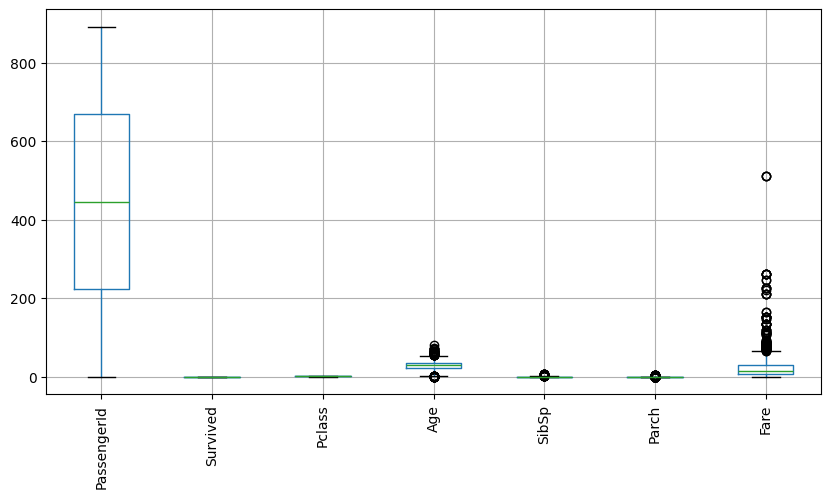

In [153]:
num=df.select_dtypes(include='number')
plt.figure(figsize=(10,5))
num.boxplot(rot=90)
plt.show()

## IQF

In [154]:

numeric_cols = df.select_dtypes(include=np.number).columns


for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower, upper)

df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"braund, mr. owen harris",male,22.000000,1.0,0,a/5 21171,7.2500,NaN,s
1,2,1,1,"cumings, mrs. john bradley (florence briggs th...",female,38.000000,1.0,0,pc 17599,65.6344,c85,c
2,3,1,3,"heikkinen, miss. laina",female,26.000000,0.0,0,ston/o2. 3101282,7.9250,NaN,s
3,4,1,1,"futrelle, mrs. jacques heath (lily may peel)",female,35.000000,1.0,0,113803,53.1000,c123,s
4,5,0,3,"allen, mr. william henry",male,35.000000,0.0,0,373450,8.0500,NaN,s
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"montvila, rev. juozas",male,27.000000,0.0,0,211536,13.0000,NaN,s
887,888,1,1,"graham, miss. margaret edith",female,19.000000,0.0,0,112053,30.0000,b42,s
888,889,0,3,"johnston, miss. catherine helen ""carrie""",female,29.699118,1.0,0,w./c. 6607,23.4500,NaN,s
889,890,1,1,"behr, mr. karl howell",male,26.000000,0.0,0,111369,30.0000,c148,c


In [155]:
from scipy.stats import zscore
import numpy as np

numeric_cols = df.select_dtypes(include=np.number)

z_scores = np.abs(zscore(numeric_cols))

#df = df[(z_scores < 3).all(axis=1)]


In [156]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"braund, mr. owen harris",male,22.000000,1.0,0,a/5 21171,7.2500,NaN,s
1,2,1,1,"cumings, mrs. john bradley (florence briggs th...",female,38.000000,1.0,0,pc 17599,65.6344,c85,c
2,3,1,3,"heikkinen, miss. laina",female,26.000000,0.0,0,ston/o2. 3101282,7.9250,NaN,s
3,4,1,1,"futrelle, mrs. jacques heath (lily may peel)",female,35.000000,1.0,0,113803,53.1000,c123,s
4,5,0,3,"allen, mr. william henry",male,35.000000,0.0,0,373450,8.0500,NaN,s
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"montvila, rev. juozas",male,27.000000,0.0,0,211536,13.0000,NaN,s
887,888,1,1,"graham, miss. margaret edith",female,19.000000,0.0,0,112053,30.0000,b42,s
888,889,0,3,"johnston, miss. catherine helen ""carrie""",female,29.699118,1.0,0,w./c. 6607,23.4500,NaN,s
889,890,1,1,"behr, mr. karl howell",male,26.000000,0.0,0,111369,30.0000,c148,c


In [157]:
from sklearn.preprocessing import LabelEncoder


df_encoded = df.copy()

le = LabelEncoder()

df_encoded["Sex"] = le.fit_transform(df_encoded["Sex"])

# One-Hot Encoding

df_encoded = pd.get_dummies(
    df_encoded,
    columns=["Embarked", "Pclass"],
    drop_first=True
)

# Display the first few rows
df_encoded.head()

,PassengerId,Survived,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_q,Embarked_s,Pclass_2,Pclass_3
0,1,0,"braund, mr. owen harris",1,22.0,1.0,0,a/5 21171,7.2500,NaN,False,True,False,True
1,2,1,"cumings, mrs. john bradley (florence briggs th...",0,38.0,1.0,0,pc 17599,65.6344,c85,False,False,False,False
2,3,1,"heikkinen, miss. laina",0,26.0,0.0,0,ston/o2. 3101282,7.9250,NaN,False,True,False,True
3,4,1,"futrelle, mrs. jacques heath (lily may peel)",0,35.0,1.0,0,113803,53.1000,c123,False,True,False,False
4,5,0,"allen, mr. william henry",1,35.0,0.0,0,373450,8.0500,NaN,False,True,False,True


## Feature Scaling

In [158]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# MinMax
scale_cols = ["Age", "Fare", "SibSp"]

df_scaled = df_encoded.copy()


minmax = MinMaxScaler()

df_minmax = df_scaled.copy()
df_minmax[scale_cols] = minmax.fit_transform(df_minmax[scale_cols])

print("Min-Max Normalization")
df_minmax[scale_cols].head()

Min-Max Normalization


,Age,Fare,SibSp
0,0.375000,0.110460,0.4
1,0.682692,1.000000,0.4
2,0.451923,0.120745,0.0
3,0.625000,0.809027,0.4
4,0.625000,0.122649,0.0


In [159]:
standard = StandardScaler()

df_standard = df_scaled.copy()
df_standard[scale_cols] = standard.fit_transform(df_standard[scale_cols])

print("Standardization (Z-score Scaling)")
df_standard[scale_cols].head()

Standardization (Z-score Scaling)


,Age,Fare,SibSp
0,-0.611917,-0.820552,0.810220
1,0.715304,2.031623,0.810220
2,-0.280111,-0.787578,-0.602512
3,0.466450,1.419297,0.810220
4,0.466450,-0.781471,-0.602512


## Correlation

In [160]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"braund, mr. owen harris",male,22.000000,1.0,0,a/5 21171,7.2500,NaN,s
1,2,1,1,"cumings, mrs. john bradley (florence briggs th...",female,38.000000,1.0,0,pc 17599,65.6344,c85,c
2,3,1,3,"heikkinen, miss. laina",female,26.000000,0.0,0,ston/o2. 3101282,7.9250,NaN,s
3,4,1,1,"futrelle, mrs. jacques heath (lily may peel)",female,35.000000,1.0,0,113803,53.1000,c123,s
4,5,0,3,"allen, mr. william henry",male,35.000000,0.0,0,373450,8.0500,NaN,s
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"montvila, rev. juozas",male,27.000000,0.0,0,211536,13.0000,NaN,s
887,888,1,1,"graham, miss. margaret edith",female,19.000000,0.0,0,112053,30.0000,b42,s
888,889,0,3,"johnston, miss. catherine helen ""carrie""",female,29.699118,1.0,0,w./c. 6607,23.4500,NaN,s
889,890,1,1,"behr, mr. karl howell",male,26.000000,0.0,0,111369,30.0000,c148,c


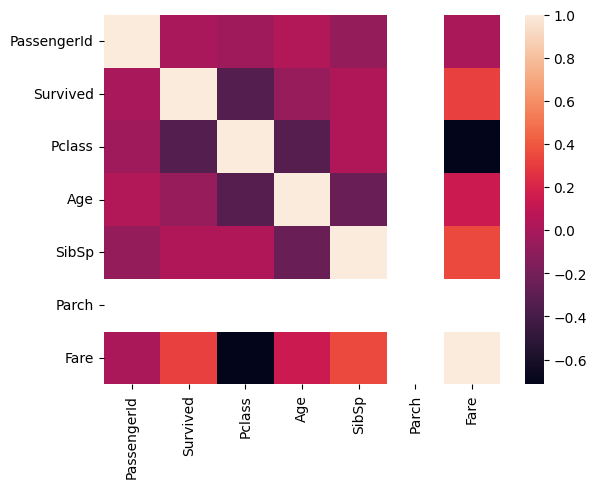

In [190]:
corr=df.corr(numeric_only=True)
sns.heatmap(corr)
plt.show()

## Feature engineering

## Convert datatypes

In [162]:
df.dtypes
df['SibSp']=df['SibSp'].astype('float64')
df['Parch']=df['Parch'].astype('float64')
df['Fare']=df['Fare'].astype('float64')

## Train test

In [191]:
X=df.drop(columns=['Survived'])
y=df['Survived']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [192]:
#balancing
from imblearn.over_sampling import RandomOverSampler
ros=RandomOverSampler(random_state=42)
X_resampled,y_resampled=ros.fit_resample(X_train,y_train)

## Compare

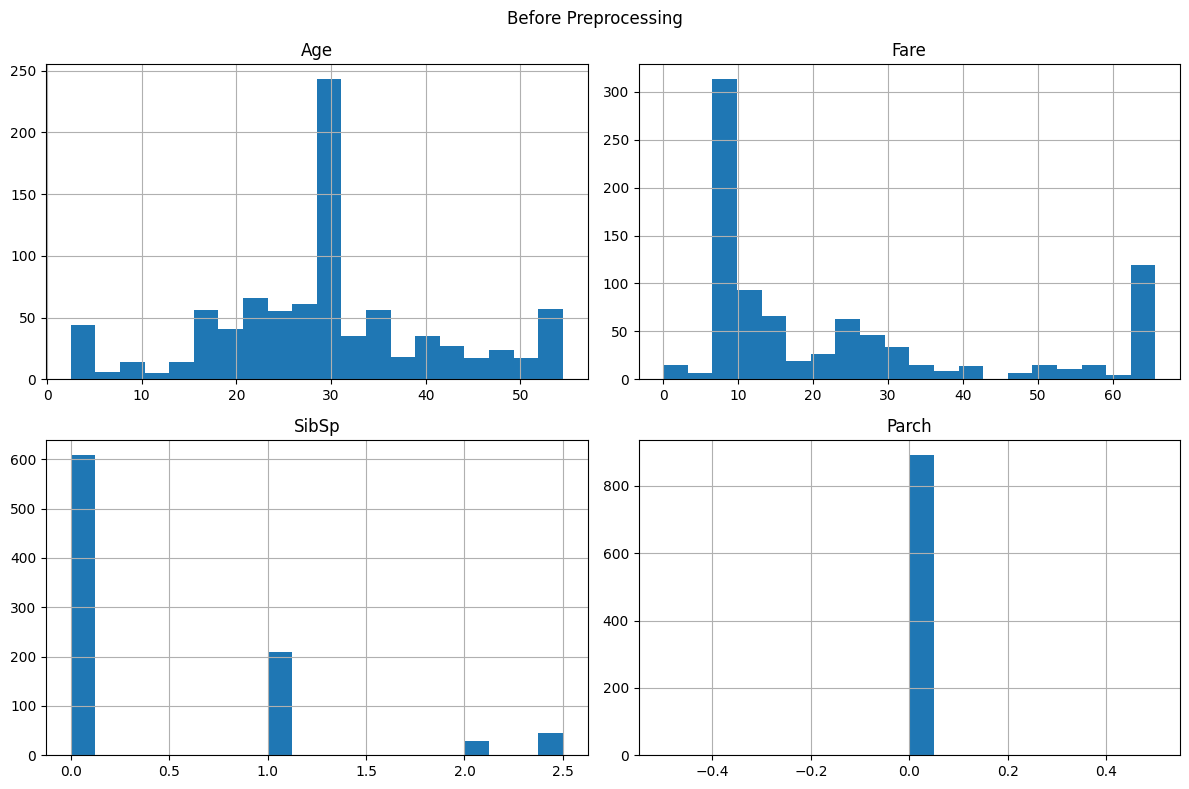

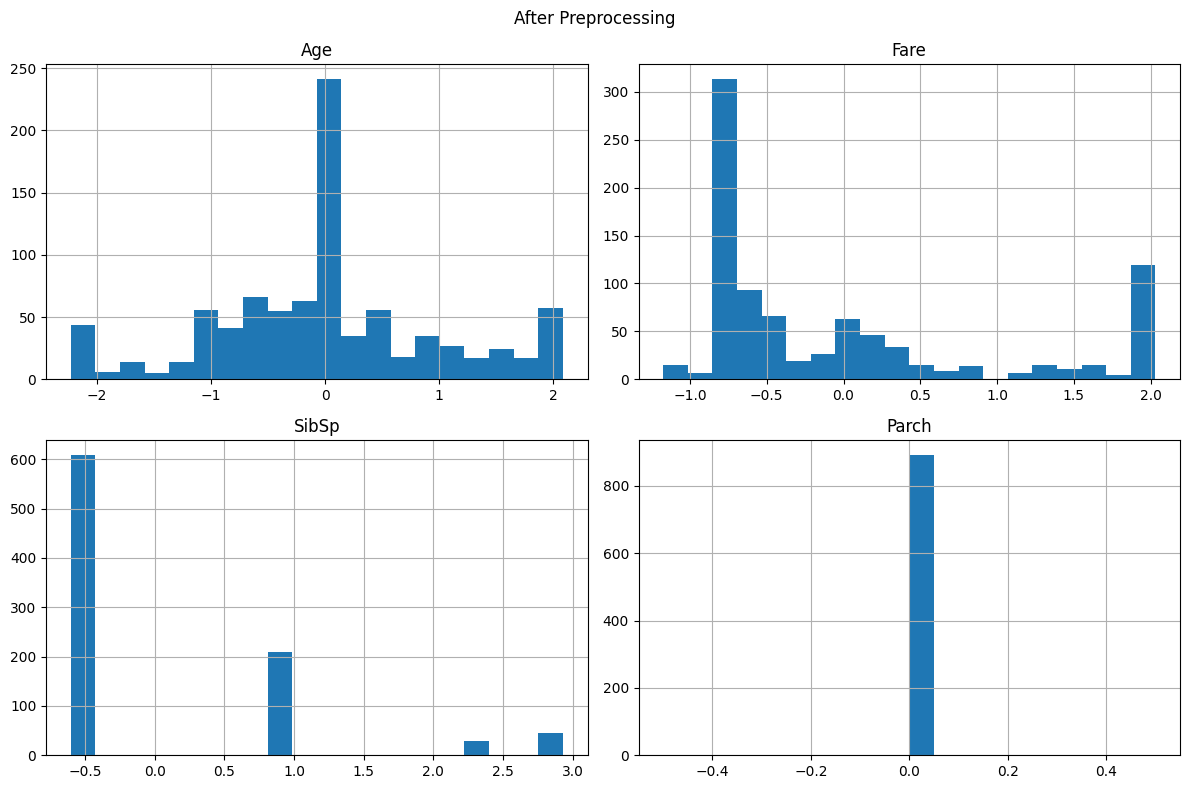

In [171]:
import matplotlib.pyplot as plt

# Numerical columns
numeric_cols = ["Age", "Fare", "SibSp", "Parch"]

# Before preprocessing
df[numeric_cols].hist(figsize=(12, 8), bins=20)
plt.suptitle("Before Preprocessing")
plt.tight_layout()
plt.show()

# After preprocessing
df_standard[numeric_cols].hist(figsize=(12, 8), bins=20)
plt.suptitle("After Preprocessing")
plt.tight_layout()
plt.show()

In [175]:

print("Before Preprocessing")
print("---------------------")
print(df.info())
df.describe(include='all')


Before Preprocessing
---------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    float64
 7   Parch        891 non-null    float64
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(4), int64(3), object(5)
memory usage: 83.7+ KB
None


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,891.000000,891.000000,891.0,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"dooley, mr. patrick",male,NaN,NaN,NaN,347082,NaN,g6,s
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.376817,0.426487,0.0,NaN,24.046813,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,12.062035,0.708246,0.0,NaN,20.481625,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,2.500000,0.000000,0.0,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,22.000000,0.000000,0.0,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,29.699118,0.000000,0.0,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,35.000000,1.000000,0.0,NaN,31.000000,NaN,NaN


In [176]:

print("\n\nAfter Preprocessing")
print("---------------------")
df_standard.info()
df_standard.describe(include='all')



After Preprocessing
---------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Name         891 non-null    object 
 3   Sex          891 non-null    int64  
 4   Age          891 non-null    float64
 5   SibSp        891 non-null    float64
 6   Parch        891 non-null    int64  
 7   Ticket       891 non-null    object 
 8   Fare         891 non-null    float64
 9   Cabin        204 non-null    object 
 10  Embarked_q   891 non-null    bool   
 11  Embarked_s   891 non-null    bool   
 12  Pclass_2     891 non-null    bool   
 13  Pclass_3     891 non-null    bool   
dtypes: bool(4), float64(3), int64(4), object(3)
memory usage: 73.2+ KB


,PassengerId,Survived,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked_q,Embarked_s,Pclass_2,Pclass_3
count,891.000000,891.000000,891,891.000000,8.910000e+02,8.910000e+02,891.0,891,8.910000e+02,204,891,891,891,891
unique,NaN,NaN,891,NaN,NaN,NaN,NaN,681,NaN,147,2,2,2,2
top,NaN,NaN,"dooley, mr. patrick",NaN,NaN,NaN,NaN,347082,NaN,g6,False,True,False,True
freq,NaN,NaN,1,NaN,NaN,NaN,NaN,7,NaN,4,814,644,707,491
mean,446.000000,0.383838,NaN,0.647587,7.974666e-18,1.196200e-17,0.0,NaN,9.968332e-17,NaN,NaN,NaN,NaN,NaN
std,257.353842,0.486592,NaN,0.477990,1.000562e+00,1.000562e+00,0.0,NaN,1.000562e+00,NaN,NaN,NaN,NaN,NaN
min,1.000000,0.000000,NaN,0.000000,-2.229467e+00,-6.025120e-01,0.0,NaN,-1.174727e+00,NaN,NaN,NaN,NaN,NaN
25%,223.500000,0.000000,NaN,0.000000,-6.119166e-01,-6.025120e-01,0.0,NaN,-7.882908e-01,NaN,NaN,NaN,NaN,NaN
50%,446.000000,0.000000,NaN,1.000000,2.673527e-02,-6.025120e-01,0.0,NaN,-4.686152e-01,NaN,NaN,NaN,NaN,NaN
75%,668.500000,1.000000,NaN,1.000000,4.664504e-01,8.102200e-01,0.0,NaN,3.396748e-01,NaN,NaN,NaN,NaN,NaN


## Save

In [166]:
df.to_csv('cleaned_dataset.csv',index=False)